In [16]:
import pandas as pd
import matplotlib.pyplot as plt

climate_change = pd.read_csv('climate_change.csv', parse_dates=['date'], index_col='date')

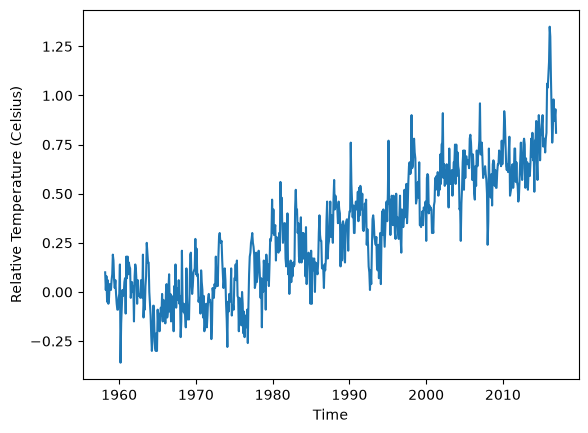

In [17]:
fig, ax = plt.subplots()
ax.plot(climate_change.index, climate_change['relative_temp'])
ax.set_xlabel('Time')
ax.set_ylabel('Relative Temperature (Celsius)')
plt.show()

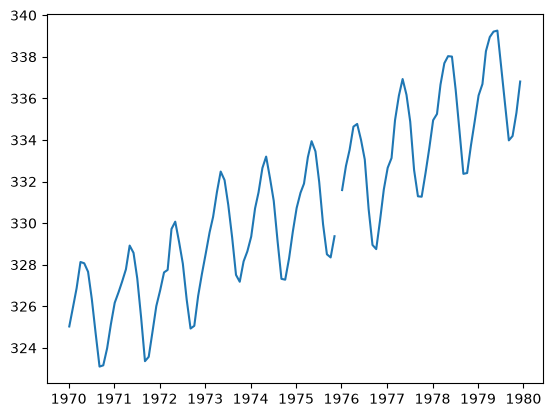

In [18]:
fig, ax = plt.subplots()

seventies = climate_change['1970-01-01':'1979-12-31']

ax.plot(seventies.index, seventies['co2'])

plt.show()

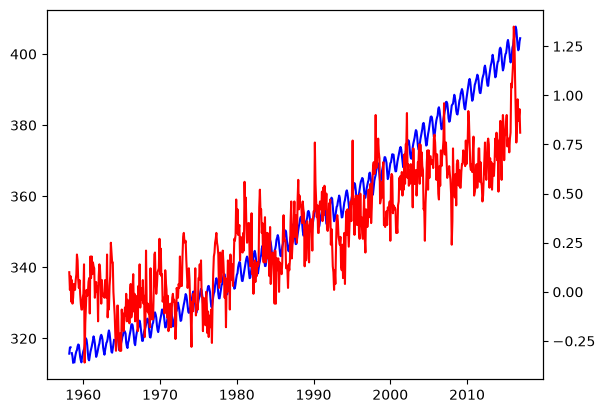

In [19]:
fig, ax = plt.subplots()

ax.plot(climate_change.index, climate_change['co2'], color='b')

ax2 = ax.twinx()

ax2.plot(climate_change.index, climate_change['relative_temp'], color='r')

plt.show()

In [20]:
def plot_timeseries(axes, x, y, color, xlabel, ylabel):
    axes.plot(x,y, color=color)
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel, color=color)
    axes.tick_params('y', colors=color)

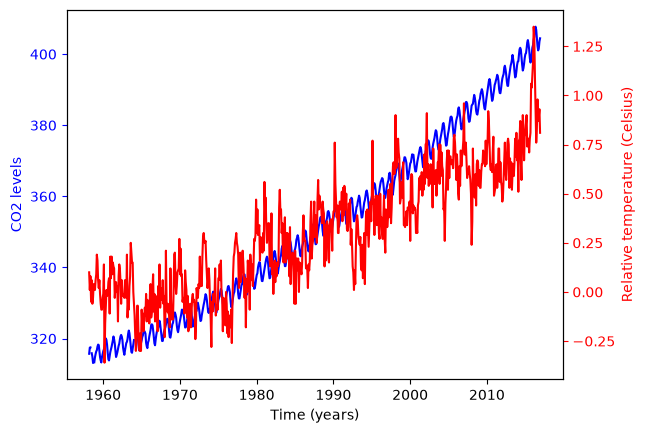

In [21]:
fig, ax = plt.subplots()

plot_timeseries(ax, climate_change.index, climate_change['co2'], 'blue', 'Time (years)', 'CO2 levels')

ax2 = ax.twinx()

plot_timeseries(ax2, climate_change.index, climate_change['relative_temp'], 'red', 'Time (years)', 'Relative temperature (Celsius)')

plt.show()

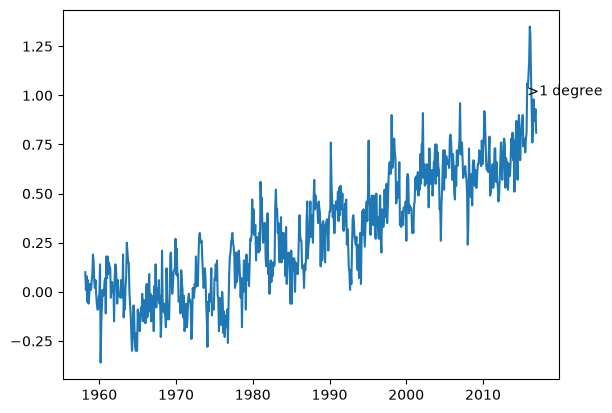

In [22]:
fig, ax = plt.subplots()

ax.plot(climate_change.index, climate_change['relative_temp'])

ax.annotate('>1 degree', xy=(pd.Timestamp('2015-10-06'), 1))

plt.show()

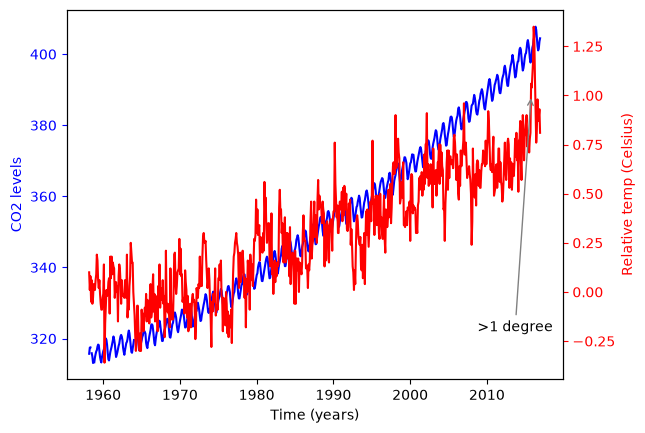

In [23]:
fig, ax = plt.subplots()

plot_timeseries(ax, climate_change.index, climate_change['co2'], 'blue', 'Time (years)', 'CO2 levels')

ax2 = ax.twinx()

plot_timeseries(ax2, climate_change.index, climate_change['relative_temp'], 'red', 'Time (years)', 'Relative temp (Celsius)')

ax2.annotate('>1 degree', xy=(pd.Timestamp('2015-10-06'), 1),
             xytext=(pd.Timestamp('2008-10-06'), -0.2),
             arrowprops={"arrowstyle":"->", "color":"gray"})

plt.show()

In [24]:
medals = pd.read_csv('medals_by_country_2016.csv', index_col=0)
medals.head()

,Bronze,Gold,Silver
United States,67,137,52
Germany,67,47,43
Great Britain,26,64,55
Russia,35,50,28
China,35,44,30


/tmp/ipykernel_2012/1787041785.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(medals.index, rotation=90)


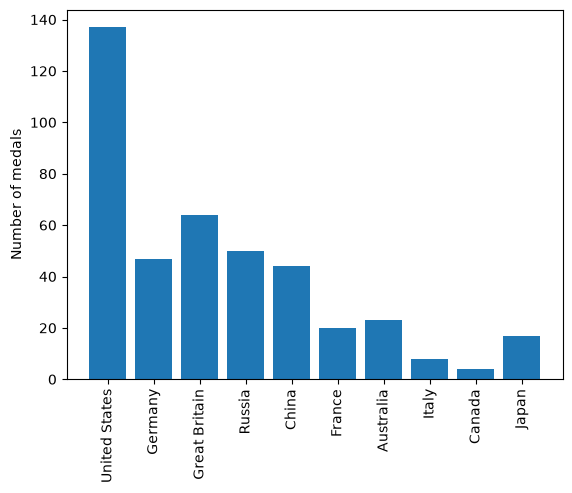

In [25]:
fig,ax = plt.subplots()
ax.bar(medals.index, medals['Gold'])
ax.set_xticklabels(medals.index, rotation=90)
ax.set_ylabel('Number of medals')

plt.show()

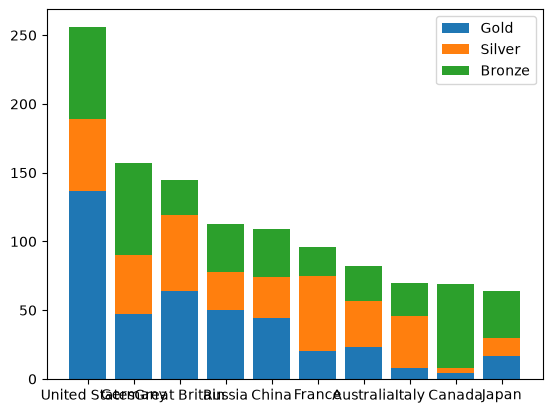

In [29]:
fig, ax = plt.subplots()

ax.bar(medals.index, medals['Gold'], label='Gold')
ax.bar(medals.index, medals['Silver'], label='Silver', bottom=medals['Gold'])
ax.bar(medals.index, medals['Bronze'], label='Bronze', bottom=medals['Gold'] + medals['Silver'])
ax.legend()
plt.show()

In [42]:
summer2016 = pd.read_csv('summer2016.csv')
mens_gymnastics = summer2016[summer2016['Sport'] == 'Gymnastics']
mens_rowing = summer2016[summer2016['Sport'] == 'Rowing']

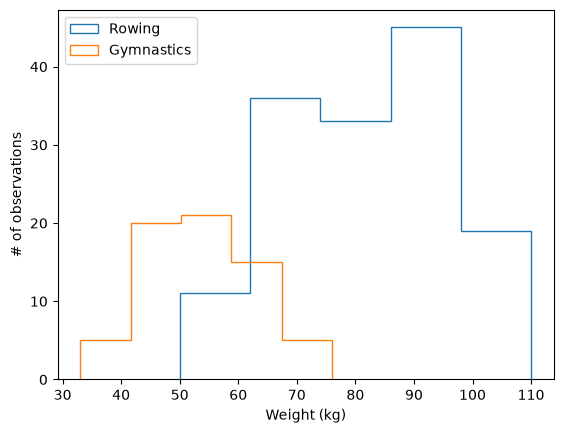

In [48]:
fig, ax = plt.subplots()
ax.hist(mens_rowing['Weight'], label='Rowing', histtype='step', bins=5)
ax.hist(mens_gymnastics['Weight'], label='Gymnastics', histtype='step', bins=5)
ax.set_xlabel('Weight (kg)')
ax.set_ylabel('# of observations')
ax.legend()
plt.show()

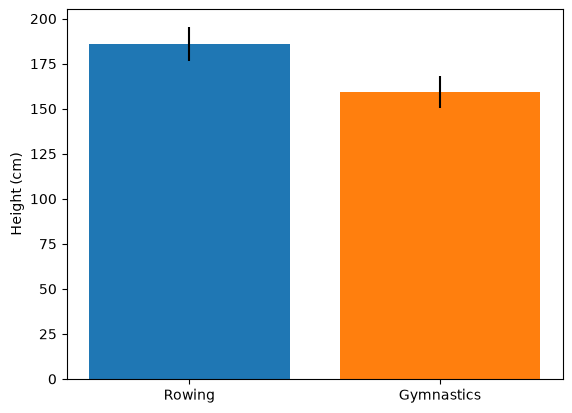

In [49]:
fig, ax = plt.subplots()
ax.bar('Rowing', mens_rowing['Height'].mean(), yerr=mens_rowing['Height'].std())
ax.bar('Gymnastics', mens_gymnastics['Height'].mean(), yerr=mens_gymnastics['Height'].std())
ax.set_ylabel('Height (cm)')
plt.show()

## Gráfico de Barras con Barras de Error

Este gráfico compara la **altura promedio** de atletas de dos deportes diferentes (Remo vs Gimnasia).

**Componentes principales:**

- **Altura de la barra**: Representa el valor promedio (media) de la altura. Calculado con `.mean()`
- **Barras de error (líneas verticales)**: Muestran la **desviación estándar** (std). Indica cuánto varían los datos alrededor del promedio.
  - Si la barra de error es grande → hay mucha variabilidad en las alturas
  - Si la barra de error es pequeña → las alturas son más similares entre los atletas

**¿Por qué son útiles las barras de error?**
No solo nos muestran el promedio, sino también la variabilidad o dispersión de los datos. Así podemos ver si todos los atletas tienen alturas similares o si hay mucha diferencia entre ellos.

**En este caso:**
- Remo: los atletas tienden a tener alturas más variadas (barra de error más grande)
- Gimnasia: los atletas tienen alturas más uniformes (barra de error más pequeña)